### This is a test/tutorial notebook for pipeline

In [4]:
import sys
import os
import pickle
sys.path.append("../unwrap2D/")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from tifffile import imread, imwrite
from copy import deepcopy
import importlib
import Step2_bp_forwardeuler_GVF
importlib.reload(Step2_bp_forwardeuler_GVF)
from Step0_rotation_translation_registration import img_translation, rotation_registration
from Step1_bp_demon_registration import frame_by_frame_demon_registration
from Step2_bp_forwardeuler_GVF import boundary_propagation_with_anomaly_detection, boundary_propagation_with_anomaly_detection_fix_boundary,\
    save_matplot_video, reorder_igl_boundary_stack, extract_igl_boundary_stack
from Step3_uv_interpolation import generate_bdy_uv, interpolate_2nn_stack
from Step4_run_unwrap2D import parallel_unwrap2D, parallel_resample_img
import unwrap2D as unwrap2D_fns

sys.path.append("../utils/")

from plot_functions import save_overlay_plot



In [5]:
img_stack = imread("../example_data/Collins_data/cell.tif").astype(np.float32)
mask_stack = imread("../example_data/Collins_data/cell_mask.tif").astype(np.float32)

In [6]:
# visualization saving path
vis_save_path = "/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/data/Collins_Data_Processed/step4_2015_paper_registration_stilltesting/2013-05-24_Gradient_protocol_Cell1"

# Step 0: Preprocess (rigid registration)

In [7]:
# first perform translation to center the cell
from scipy.ndimage import shift
step0_savepath = os.path.join(vis_save_path, "Step0_rigid_registration_centroid")
os.makedirs(step0_savepath, exist_ok=True)

centered_img_stack = []
centered_mask_stack = []
for ii, (img, mask) in enumerate(zip(img_stack,mask_stack)):
    centered_img, center, (dy, dx) = img_translation(img, cMCF_center=False)
    centered_mask = shift(mask, shift=(dy, dx), order=0, prefilter=False, mode='nearest')
    filename = os.path.join(step0_savepath,  f"{ii+1:03}.tiff")
    imwrite(filename, centered_img)
    centered_img_stack.append(centered_img)
    centered_mask_stack.append(centered_mask)
centered_img_stack = np.array(centered_img_stack)
centered_mask_stack = np.array(centered_mask_stack)

In [8]:
# Then perform rotation-wise translation
figure_savepath = os.path.join(vis_save_path, "Step0_rotation")
os.makedirs(figure_savepath,exist_ok=True)
switch_n = 5
rigid_registered_stack = [centered_img_stack[0]]
rigid_registered_mask = [centered_mask_stack[0]]
fixed_img = rigid_registered_stack[-1].copy()


for jj in np.arange(1, centered_img_stack.shape[0]):
        
        if np.mod(jj, switch_n) == 0:
            
            fixed_img = rigid_registered_stack[-1].copy()
        
        # ii = jj

        moving_img = deepcopy(centered_img_stack[jj])
        mask = centered_mask_stack[jj]
        
        resampled_np, metrics, registered_mask = rotation_registration(fixed_img, moving_img, [mask])
        rigid_registered_stack.append(resampled_np)
        rigid_registered_mask.append(registered_mask[0])
        plt.figure(figsize=(15,10))
        plt.subplot(121); plt.title('no-register')
        plt.imshow(fixed_img, cmap='Reds')
        plt.imshow(moving_img, cmap='Greens', alpha=0.5)
        plt.axis('off'); plt.grid('off')
        plt.subplot(122); plt.title('register')
        plt.imshow(fixed_img, cmap='Reds')
        plt.imshow(resampled_np, cmap='Greens', alpha=0.5)
        # plt.imshow(moving_img, cmap='Blues', alpha=0.25)
        plt.axis('off'); plt.grid('off')
        # plt.subplot(133); plt.title('register')
        # plt.imshow(fixed_img, cmap='Reds')
        # plt.imshow(registered_extra[0], cmap='Greens', alpha=0.5)
        # #plt.imshow(moving_img, cmap='Blues', alpha=0.25)
        # plt.axis('off'); plt.grid('off')
        plt.savefig(os.path.join(figure_savepath, f"frame_{jj}.png"))

        plt.close()

rigid_registered_stack = np.array(rigid_registered_stack)
rigid_registered_mask = np.array(rigid_registered_mask)


imwrite(os.path.join(vis_save_path, "Step0_rotation_test/cell.tif"),rigid_registered_stack)
imwrite(os.path.join(vis_save_path, "Step0_rotation_test/mask.tif"),rigid_registered_mask)


gradient
Final metric value: -0.2259217846167343
Optimizer's stopping condition, RegularStepGradientDescentOptimizerv4: Step too small after 966 iterations. Current step (9.09495e-13) is less than minimum step (1e-12).
gradient
Final metric value: -0.22136388804887636
Optimizer's stopping condition, RegularStepGradientDescentOptimizerv4: Step too small after 648 iterations. Current step (9.09495e-13) is less than minimum step (1e-12).
gradient
Final metric value: -0.21262166268155816
Optimizer's stopping condition, RegularStepGradientDescentOptimizerv4: Step too small after 2034 iterations. Current step (9.09495e-13) is less than minimum step (1e-12).
gradient
Final metric value: -0.19416140196958692
Optimizer's stopping condition, RegularStepGradientDescentOptimizerv4: Step too small after 242 iterations. Current step (9.09495e-13) is less than minimum step (1e-12).
gradient
Final metric value: -0.22551132588533998
Optimizer's stopping condition, RegularStepGradientDescentOptimizerv4:

In [9]:
rigid_registered_stack = imread(os.path.join(vis_save_path, "Step0_rotation_test/cell.tif"))
rigid_registered_mask = imread(os.path.join(vis_save_path, "Step0_rotation_test/mask.tif"))

# Step 1: perform demon registration

In [10]:
registered_stack, ori_img_stack, displacement_fields_stack, mses = frame_by_frame_demon_registration(rigid_registered_mask, 
                                                                                                        shrink_factor = [8, 4, 2, 1.], 
                                                                                                        smooth_alpha = 1,
                                                                                                        smoothing_sigmas=[1, 1, 1, 1],
                                                                                                        n_iters=800)

  0%|          | 0/83 [00:00<?, ?it/s]

100%|██████████| 83/83 [31:23<00:00, 22.69s/it]

mean mses: 0.00031785996
mse std: 6.515729e-05


In [11]:
# save visualization and results
save_dir = os.path.join(vis_save_path,"2013-05-24_Gradient_protocol_Cell1/test_results")
os.makedirs(save_dir, exist_ok=True)
for ii, (ori, reg) in tqdm(enumerate(zip(ori_img_stack, registered_stack))):
    save_overlay_plot(ori_img_stack[ii-1], reg, save_dir, frame_idx=ii)

import pickle
with open(os.path.join(save_dir, 'displacement_fields_stack.pkl'), 'wb') as f:
    pickle.dump(displacement_fields_stack, f)

NameError: name 'tqdm' is not defined

In [18]:
save_dir = os.path.join(vis_save_path,"2013-05-24_Gradient_protocol_Cell1/test_results")
with open(os.path.join(save_dir, 'displacement_fields_stack.pkl'), 'rb') as f:
    displacement_fields_stack = pickle.load(f)

# Step 2: GVF

In [10]:
# igl_unwarped_boundary_stack, mesh_2D_submesh_stack, _ = extract_igl_boundary_stack(rigid_registered_mask)
# #igl_unwarped_reordered_boundary_stack = reorder_igl_boundary_stack(igl_unwarped_boundary_stack)
# last_frame_boundary = igl_unwarped_boundary_stack[0]
# boundary_points_stack_euler = [last_frame_boundary]
# before_map_stack_euler = [last_frame_boundary]
# n_samples = len(igl_unwarped_boundary_stack[0])

  5%|▍         | 4/83 [00:58<19:00, 14.44s/it]

==== Anomaly detected ====
frame: 5, disp_mean_curr: 21.4886, disp_hist_mean: 10.6370, disp_hist_std: 2.0692
portion_curr: 3.9794, port_hist_mean: 1.3597, port_hist_std: 0.4083
contour distance: 0.6069, ct_dist_mean_hist: 0.6258, ct_dist_std_hist: 0.0213


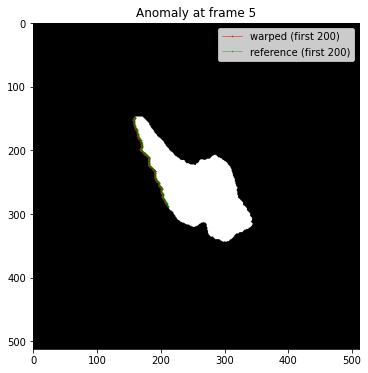

  6%|▌         | 5/83 [01:12<18:49, 14.48s/it]

==== Anomaly detected ====
frame: 6, disp_mean_curr: 44.0143, disp_hist_mean: 12.8073, disp_hist_std: 4.7187
portion_curr: 1.9060, port_hist_mean: 1.8836, port_hist_std: 1.1097
contour distance: 0.6397, ct_dist_mean_hist: 0.6220, ct_dist_std_hist: 0.0205


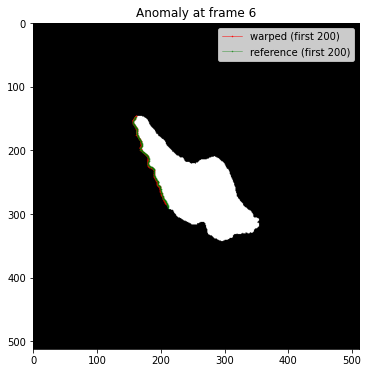

 58%|█████▊    | 48/83 [12:25<08:35, 14.73s/it]

==== Anomaly detected ====
frame: 49, disp_mean_curr: 85.2874, disp_hist_mean: 28.8824, disp_hist_std: 11.0808
portion_curr: 0.6565, port_hist_mean: 0.7717, port_hist_std: 0.7380
contour distance: 0.7574, ct_dist_mean_hist: 0.6255, ct_dist_std_hist: 0.0305


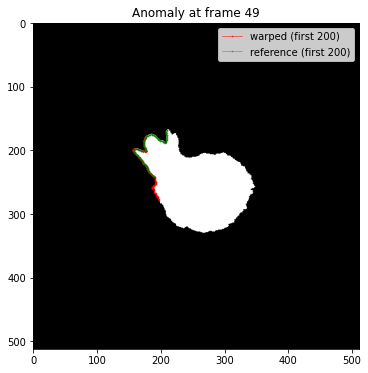

100%|██████████| 83/83 [21:27<00:00, 15.51s/it]


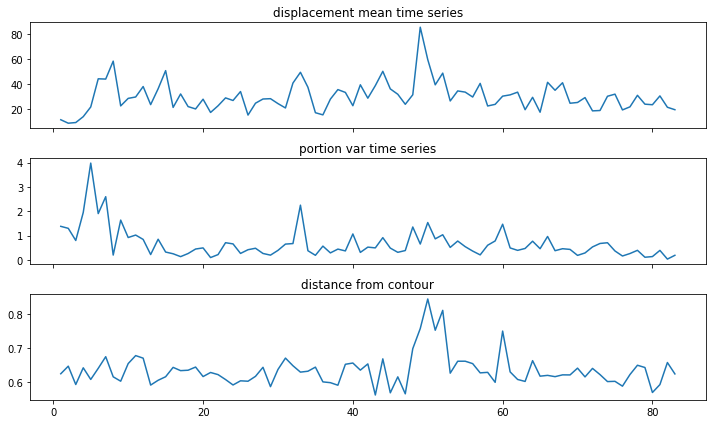

In [ ]:
igl_unwarped_boundary_stack, mesh_2D_submesh_stack, _ = extract_igl_boundary_stack(rigid_registered_mask)

output_dir = os.path.join(vis_save_path,"GVF")
os.makedirs(output_dir, exist_ok=True)
boundary_points_stack_euler, pure_resample = boundary_propagation_with_anomaly_detection(
                                             
                                                displacement_fields_stack, 
                                                rigid_registered_mask,
                                                igl_unwarped_boundary_stack, 
                                                output_dir,
                                                window_size = 6,      
                                                sigma_thresh = 3.0,  
                                                min_history = 5,       
                                                contour_distance_thres = 3.0,
                                                stats_plot = True)

In [30]:
# Compare pure resampled boundary and tracked boundary proportion

save_name = f"forward_euler_after_rotation_registration_pure_resample"
save_folder = os.path.join(vis_save_path, "boundary_visualization")
os.makedirs(save_folder, exist_ok=True)
save_matplot_video(rigid_registered_stack, pure_resample, save_folder, save_name, colormap='gray',img_plot=True,scatter = False, plot_multiple_point = True)

save_name = f"forward_euler_after_rotation_registration_100iter_lambda05_scatter_anomaly_detection"
save_folder = os.path.join(vis_save_path, "boundary_visualization")
os.makedirs(save_folder, exist_ok=True)
save_matplot_video(rigid_registered_stack, boundary_points_stack_euler, save_folder, save_name, colormap='gray',img_plot=True,scatter = False, plot_multiple_point = True)

with open(os.path.join(vis_save_path, 'boundary_points_stack_euler_anomaly_detection.pkl'), 'wb') as f:
    pickle.dump(boundary_points_stack_euler, f)

 17%|█▋        | 14/83 [03:32<17:03, 14.84s/it]

[frame 14] detected disordered runs (global order change): [(0, 4)]


 22%|██▏       | 18/83 [04:30<15:46, 14.57s/it]

[frame 18] detected disordered runs (global order change): [(391, 395)]


 40%|███▉      | 33/83 [08:11<12:28, 14.98s/it]

...

 66%|██████▋   | 55/83 [13:31<06:39, 14.28s/it]

[frame 55] detected disordered runs (global order change): [(737, 741)]


 67%|██████▋   | 56/83 [13:45<06:22, 14.18s/it]

[frame 56] detected disordered runs (global order change): [(742, 746)]


100%|██████████| 83/83 [20:22<00:00, 14.73s/it]


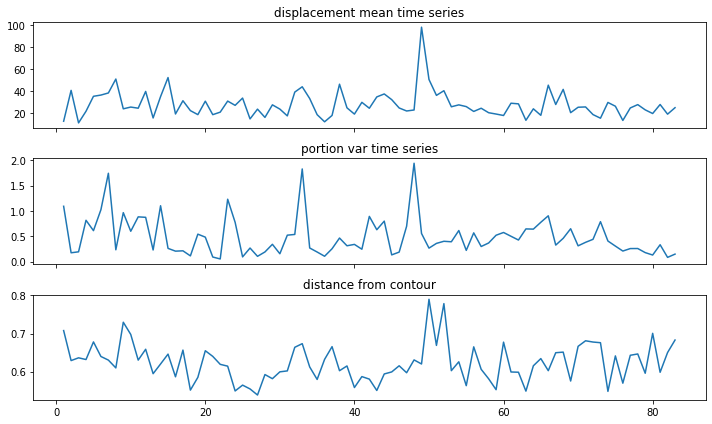

In [35]:
boundary_points_stack_euler, pure_resample = boundary_propagation_with_anomaly_detection_fix_boundary(
                                            
                                                displacement_fields_stack, 
                                                rigid_registered_mask,
                                                igl_unwarped_boundary_stack, 
                                                output_dir,
                                                window_size = 6,      
                                                sigma_thresh = 3.0,  
                                                min_history = 5,       
                                                contour_distance_thres = 3.0,
                                                stats_plot = True)

In [37]:
# Compare pure resampled boundary and tracked boundary proportion

save_name = f"forward_euler_after_rotation_registration_pure_resample_fix_disorder"
save_folder = os.path.join(vis_save_path, "boundary_visualization")
os.makedirs(save_folder, exist_ok=True)
save_matplot_video(rigid_registered_stack, pure_resample, save_folder, save_name, colormap='gray',img_plot=True,scatter = False, plot_multiple_point = True)

save_name = f"forward_euler_after_rotation_registration_100iter_lambda05_scatter_fix_disorder"
save_folder = os.path.join(vis_save_path, "boundary_visualization")
os.makedirs(save_folder, exist_ok=True)
save_matplot_video(rigid_registered_stack, boundary_points_stack_euler, save_folder, save_name, colormap='gray',img_plot=True,scatter = False, plot_multiple_point = True)

with open(os.path.join(vis_save_path, 'boundary_points_stack_euler_fix_disorder.pkl'), 'wb') as f:
    pickle.dump(boundary_points_stack_euler, f)

# Step 3: UV interpolation

In [100]:
mesh_2D_submesh, disk_coords, bdy_uv_0, bdy_index = generate_bdy_uv(mesh_2D_submesh_stack[0])
igl_unwarped_reordered_boundary_stack = reorder_igl_boundary_stack(igl_unwarped_boundary_stack, boundary_points_stack_euler)
bdy_uv_stack = interpolate_2nn_stack(boundary_points_stack_euler, igl_unwarped_reordered_boundary_stack, bdy_uv_0)

# Step4: Mapping to Disk with interpolated UV

In [147]:
import Step4_run_unwrap2D
importlib.reload(Step4_run_unwrap2D)
from Step4_run_unwrap2D import parallel_unwrap2D,parallel_resample_img
import unwrap2D
importlib.reload(unwrap2D)

<module 'unwrap2D' from '/endosome/work/bioinformatics/s440708/python-applications/Unwrap2D/tutorial/../unwrap2D/unwrap2D.py'>

In [142]:
save_path = os.path.join(vis_save_path, "unwrap2D_pickle")
v_out_stack, f_steps_out_stack, v_img_out_stack, bdy_index_stack = parallel_unwrap2D(img_stack, mask_stack, bdy_uv_stack, igl_unwarped_reordered_boundary_stack, mesh_2D_submesh_stack, save_path = save_path)

100%|██████████| 100/100 [01:49<00:00,  1.10s/it]


In [148]:
unwrap_params_stack, unwrap_img_stack, unwrap_mask_stack = parallel_resample_img(v_out_stack, v_img_out_stack, f_steps_out_stack, img_stack, save_path = save_path)


Resampling: 100%|██████████| 84/84 [02:00<00:00,  1.44s/it]


In [154]:
img_save_path = os.path.join(vis_save_path,"unwrap2D_img")
vmin = np.min(unwrap_img_stack)
vmax = np.max(unwrap_img_stack)
os.makedirs(img_save_path,exist_ok=True)
for ii, img in enumerate(unwrap_img_stack):
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(img, cmap='magma', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.tick_params(color='white', labelcolor='white')
    cbar.set_label('Intensity', color='white')
    cbar.outline.set_edgecolor('white')
    plt.savefig(os.path.join(img_save_path, f"frame_{ii+1}.tif"),
                dpi=600, bbox_inches='tight')
    plt.close()

In [13]:
from tifffile import imread
cell = imread("/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/data/Lou_data/Shared Folder with UTSW/RhoA-Rac1 in MEF Blebbistatin treated/2025-12-22 MEF RhoA-Rac1 Blebbistatin1/P1/Cell2/vcRatio_Rac1_P1C2.stk")


In [14]:
import numpy as np
from tifffile import imwrite
mask = (cell > 0).astype(np.uint16)
imwrite("/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/data/Lou_data/Shared Folder with UTSW/RhoA-Rac1 in MEF Blebbistatin treated/2025-12-22 MEF RhoA-Rac1 Blebbistatin1/P1/Cell2/mask.tif", mask)